# Sheet 2

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde

## 1 Kernel Density Estimation
(a)

In [2]:
def biweight(x, mu, w):
    """biweight kernel at mean mu, with bandwidth w evaluated at x"""
    #TODO: implement the quartic (biweight) kernel
    kernel = 15/(16*w) * (1-((x-mu)/w)**2)**2
    #set all values to zero that are not within the support
    kernel = np.where((x < mu - w ) | ( x > mu + w), 0, kernel)
    return kernel

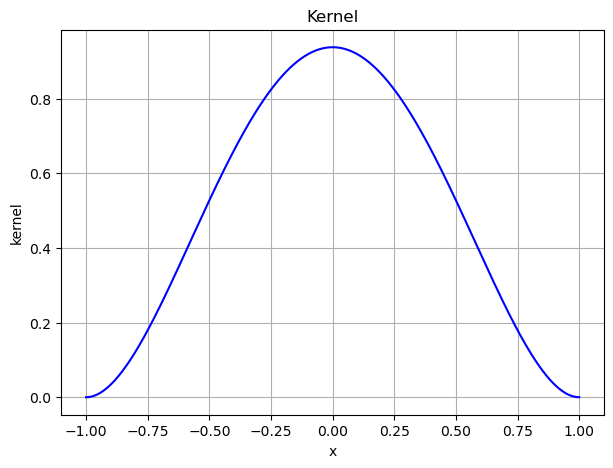

In [3]:
# TODO plot the kernel

#specify params
mu = 0
w = 1

x = np.linspace(-1,1,1000)

plt.figure(figsize=(7, 5))

plt.plot(x , biweight(x, mu, w), color = 'blue')
plt.title('Kernel')
plt.xlabel('x')
plt.ylabel('kernel')
plt.grid(True)
plt.show()


(b)

In [4]:
# load the data
data = np.load("data/samples.npy")
data50 = data[:50]
print(f'{data.shape=}, {data50.shape=}')
print(max(data), min(data))

data.shape=(10000,), data50.shape=(50,)
19.750676516320073 -9.477762185934377


In [5]:
def kde(x, obs, w=1):
    # TODO: implement the KDE with the biweight kernel
    density = np.zeros_like(x)
    for point in obs:
        density += biweight(x, point, w)
    density /= len(obs)
    return density



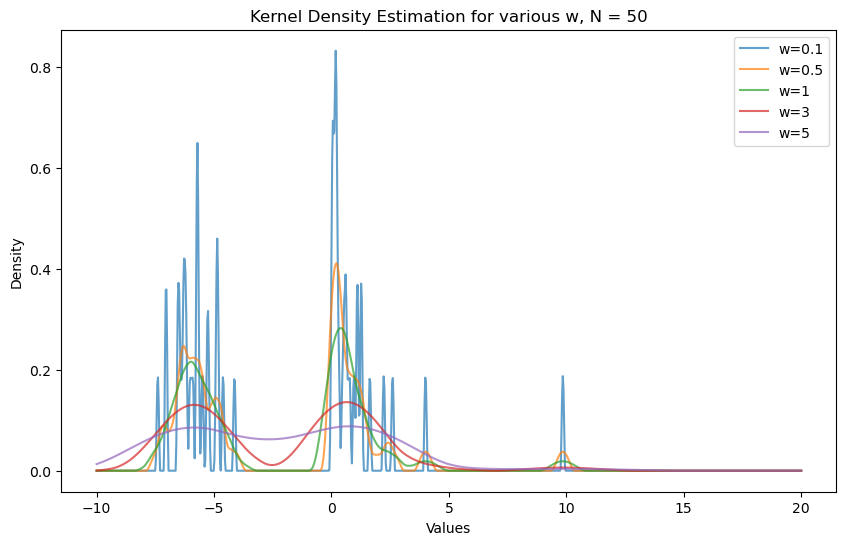

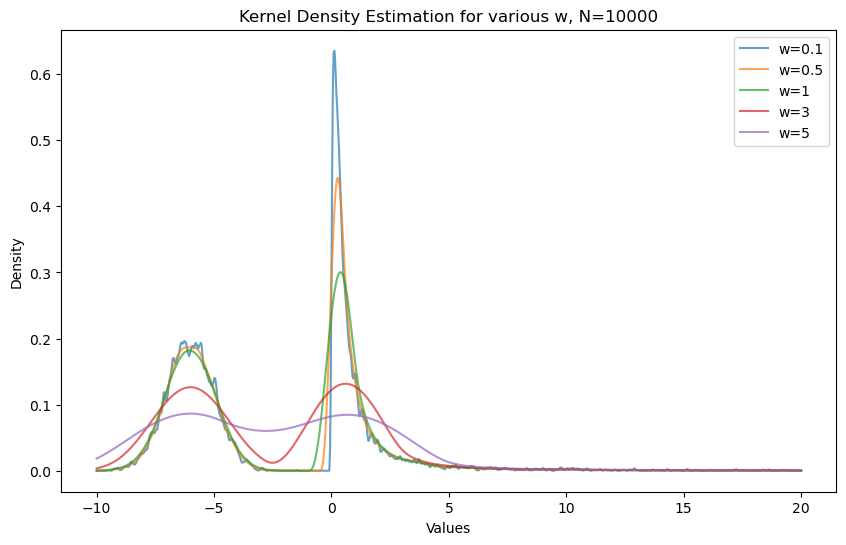

In [6]:
# TODO: compute and plot the kde on the first 50 data points
x = np.linspace(-10,20,1000)
ws =[0.1,0.5,1,3,5]

plt.figure(figsize=(10,6))

for index, w in enumerate(ws):
    density = kde(x, data50, w)
    plt.plot(x, density, label=f'w={w}', alpha = 0.7)

    plt.legend(f'w = ')
    plt.title('Values')
    plt.ylabel('Density')
    plt.grid(True)  

plt.title('Kernel Density Estimation for various w, N = 50')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend() 
plt.grid() 

plt.show()

# TODO: explore what happens when you increase the number of points

plt.figure(figsize=(10,6))

for index, w in enumerate(ws):
    density = kde(x, data, w)
    plt.plot(x, density, label=f'w={w}', alpha = 0.7)

    plt.legend(f'w = ')
    plt.title('Values')
    plt.ylabel('Density')
    plt.grid(True)  

plt.title('Kernel Density Estimation for various w, N=10000')
plt.xlabel('Values')
plt.ylabel('Density')
plt.legend() 
plt.grid() 

plt.show()

Lets take as the optimum bandwidth the one with the smallest w, where the density is smooth enough to be considered an actual density, not just a detector. 
With this in mind, in the first case (N=50), the optimum bandwidth would be either w = 0.5, or w = 1. w = 0.1 would just detect distinct events, which is no density estimation for our purposes.
In the second case (N=10000) the high number of datapoints is smoothing the data to begin with. Therefore, a lower w can be chosen. In this case this would be w = 0.5 or even lower -> 0.1 could also work. 

## 3 Mean-Shift
(b)

In [7]:
import numpy as np

In [8]:
# TODO: implement the update to the local mean

def mean_shift_step(x, xt, r=1):
    """
    A single step of mean shift, moving every point in xt to the local mean of points in x within a radious of r.
    
    Parameters
    ----------
    x : np.ndarray
        Array of points underlying the KDE, shape (d, N1)
    xt : np.ndarray
        Current state of the mean shift algorithm, shape (d, N2)
    radius : neighborhodd 
        
    Returns
    -------
    np.ndarray
        the points after the mean-shift step
    """
    # NOTE: For the excercise you only need to implement this for d == 1. 
    #       If you want some extra numpy-practice, implement it for arbitrary dimension
    
    assert xt.shape[0] == x.shape[0], f'Shape mismatch: {x.shape[0]}!={xt.shape[0]}'
    
    # TODO: start by computing a N by N matrix 'dists' of distances, 
    #       such that dists[i, j] is the distance between x[i] and xt[j]

    dists = np.zeros((x.shape[0],x.shape[0]))

    for i in range(x.shape[0]):
        for j in range(xt.shape[0]):
            dists [i,j] = np.abs(x[i] - xt[j])

    # for each point xt find the indices of the points in x that live in the radius r of xt
    local_mean = np.zeros_like(xt)
    for j in range(xt.shape[0]):
        within_radius = dists[:,j] < r

        #local mean
        if np.any(within_radius):
            local_mean[j] = np.mean(x[within_radius])
        else:
            local_mean[j] = xt[j]


    return local_mean
    

C:\Users\Felix\AppData\Local\Temp\ipykernel_8872\3076610452.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_clusters))


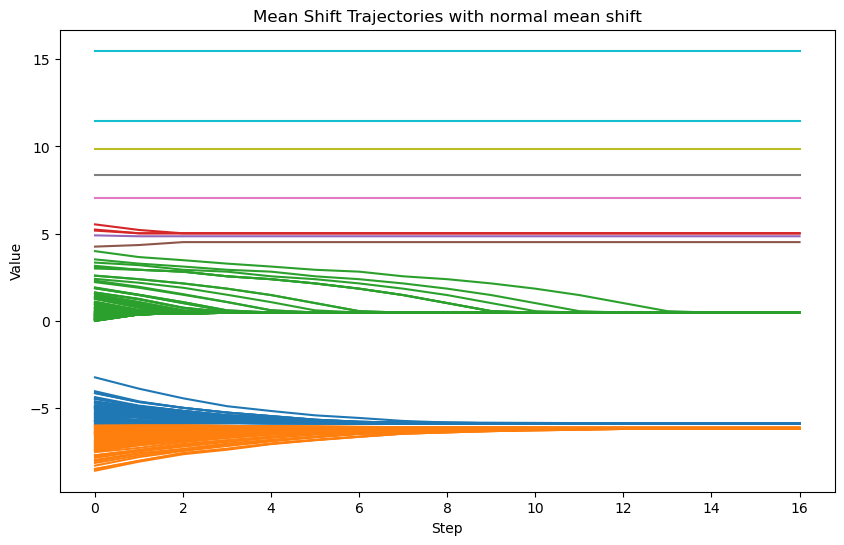

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import fclusterdata

# Load the data
data = np.load("data/samples.npy")
x = data[:300]  
xt = x.copy() 
trajectories = [xt]
max_steps = 100

# Mean Shift Iteration
for step in range(max_steps):
    xt = mean_shift_step(x, xt)  # Perform mean shift step
    trajectories.append(xt.copy())  # Store the new state of xt
    
    if np.allclose(trajectories[-1], trajectories[-2]):  # Check for convergence
        break

# Stack trajectories for easier handling
trajectories = np.stack(trajectories)

# colour the lines by final position
final_positions = trajectories[-1]
clusters = fclusterdata(final_positions.reshape(-1, 1), t=0.1, criterion='distance')
unique_clusters = np.unique(clusters)
colors = plt.cm.get_cmap('tab10', len(unique_clusters))

# Plot the trajectories with colors based on clusters
plt.figure(figsize=(10, 6))
for index in range(trajectories.shape[1]):
    plt.plot(trajectories[:, index], color=colors(clusters[index] - 1), label=f'Point {index + 1}')

plt.title('Mean Shift Trajectories with normal mean shift')
plt.xlabel('Step')
plt.ylabel('Value')
plt.show()


In [10]:
# TODO: repeat the above for "blurring" mean shift
def mean_shift_step_blurring(x, xt, r=1):
    """
    A single step of mean shift, moving every point in xt to the local mean of points in the current xt within a radious of r.
    
    Parameters
    ----------
    x : np.ndarray
        Array of points underlying the KDE, shape (d, N1)
    xt : np.ndarray
        Current state of the mean shift algorithm, shape (d, N2)
    radius : neighborhodd 
        
    Returns
    -------
    np.ndarray
        the points after the mean-shift step
    """
    # NOTE: For the excercise you only need to implement this for d == 1. 
    #       If you want some extra numpy-practice, implement it for arbitrary dimension
    
    assert xt.shape[0] == x.shape[0], f'Shape mismatch: {x.shape[0]}!={xt.shape[0]}'
    
    # TODO: start by computing a N by N matrix 'dists' of distances, 
    #       such that dists[i, j] is the distance between x[i] and xt[j]

    dists = np.zeros((x.shape[0],x.shape[0]))

    for i in range(x.shape[0]):
        for j in range(xt.shape[0]):
            dists [i,j] = np.abs(xt[i] - xt[j])

    # for each point xt find the indices of the points in x that live in the radius r of xt
    local_mean = np.zeros_like(xt)
    for j in range(xt.shape[0]):
        within_radius = dists[:,j] < r

        #local mean
        if np.any(within_radius):
            local_mean[j] = np.mean(x[within_radius])
        else:
            local_mean[j] = xt[j]


    return local_mean

C:\Users\Felix\AppData\Local\Temp\ipykernel_8872\3136166873.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_clusters))


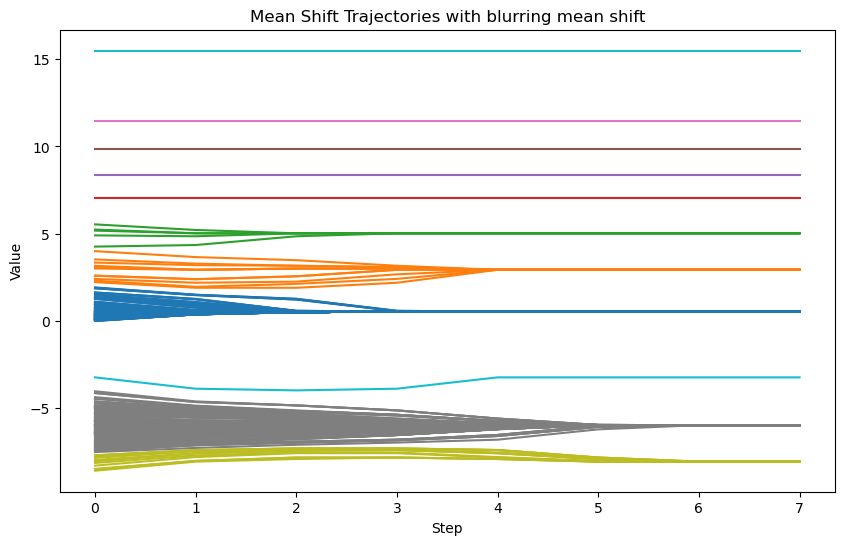

In [11]:
# Load the data
data = np.load("data/samples.npy")
x = data[:300]  
xt = x.copy() 
trajectories = [xt]
max_steps = 100

# Mean Shift Iteration
for step in range(max_steps):
    xt = mean_shift_step_blurring(x, xt)  # Perform mean shift step
    trajectories.append(xt.copy())  # Store the new state of xt
    
    if np.allclose(trajectories[-1], trajectories[-2]):  # Check for convergence
        break

# Stack trajectories for easier handling
trajectories = np.stack(trajectories)



# colour the lines by final position
final_positions = trajectories[-1]
clusters = fclusterdata(final_positions.reshape(-1, 1), t=0.1, criterion='distance')
unique_clusters = np.unique(clusters)
colors = plt.cm.get_cmap('tab10', len(unique_clusters))

# Plot the trajectories with colors based on clusters
plt.figure(figsize=(10, 6))
for index in range(trajectories.shape[1]):
    plt.plot(trajectories[:, index], color=colors(clusters[index] - 1), label=f'Point {index + 1}')

plt.title('Mean Shift Trajectories with blurring mean shift')
plt.xlabel('Step')
plt.ylabel('Value')
plt.show()


The blurring meanshift does not converge as rigorously as the normal mean shift algorithm. This arises from the observation, that the same initial data is categorized in less final clusters by the nomal mean shift algorithm. The blurring mean shift finds approximately the same clusters as the normal mean shift algorithm and on top of that some others. However, the convergence of the blurring mean shift algorithm is faster which makes it computationally less expensive. 